# 📈 Stock Price Prediction using LSTM
### Deep Learning | Time Series | LSTM | Live Data via yfinance
---
**Data Source:** Yahoo Finance (live, real-time data)  
**Model:** LSTM (Long Short-Term Memory) Neural Network  
**Goal:** Predict future stock prices from historical data  
**Stocks:** Works for ANY stock — AAPL, GOOGL, TSLA, MSFT, etc.  
---

## 📦 Step 1 — Install & Import Libraries

In [ ]:
# Install required libraries
#!pip install yfinance tensorflow scikit-learn matplotlib pandas numpy -q
# print('Installation complete!')

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print('All libraries imported!')

TensorFlow : 2.21.0
All libraries imported!


## 📥 Step 2 — Download Live Stock Data

In [2]:
# ── Configuration ────────────────────────────────────────────
STOCKS     = ['AAPL', 'GOOGL', 'TSLA', 'MSFT', 'AMZN']  # stocks to analyze
PRIMARY    = 'AAPL'   # main stock for LSTM prediction
START_DATE = '2018-01-01'
END_DATE   = '2024-12-31'
SEQ_LEN    = 60        # use last 60 days to predict next day
EPOCHS     = 50
BATCH_SIZE = 32
FUTURE_DAYS= 30        # predict next 30 days

# ── Download data for all stocks ─────────────────────────────
stock_data = {}
print('Downloading stock data...')
for ticker in STOCKS:
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    stock_data[ticker] = df
    print(f'  {ticker}: {len(df):,} trading days downloaded')

# Primary stock
df_primary = stock_data[PRIMARY].copy()
print(f'\nPrimary stock : {PRIMARY}')
print(f'Date range    : {df_primary.index[0].date()} to {df_primary.index[-1].date()}')
print(f'Total records : {len(df_primary):,}')
df_primary.tail()

  AAPL: 1,760 trading days downloaded
  GOOGL: 1,760 trading days downloaded
  TSLA: 1,760 trading days downloaded
  MSFT: 1,760 trading days downloaded
  AMZN: 1,760 trading days downloaded

Primary stock : AAPL
Date range    : 2018-01-02 to 2024-12-30
Total records : 1,760


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-12-23,253.883118,254.261043,252.072998,253.385834,40858800
2024-12-24,256.797180,256.807105,253.902972,254.101897,23234700
2024-12-26,257.612732,258.686881,256.230300,256.787255,27237100
2024-12-27,254.201370,257.294489,251.685117,256.429191,42355300
2024-12-30,250.829773,252.122713,249.387654,250.859609,35557500


## 🔍 Step 3 — Exploratory Data Analysis (EDA)

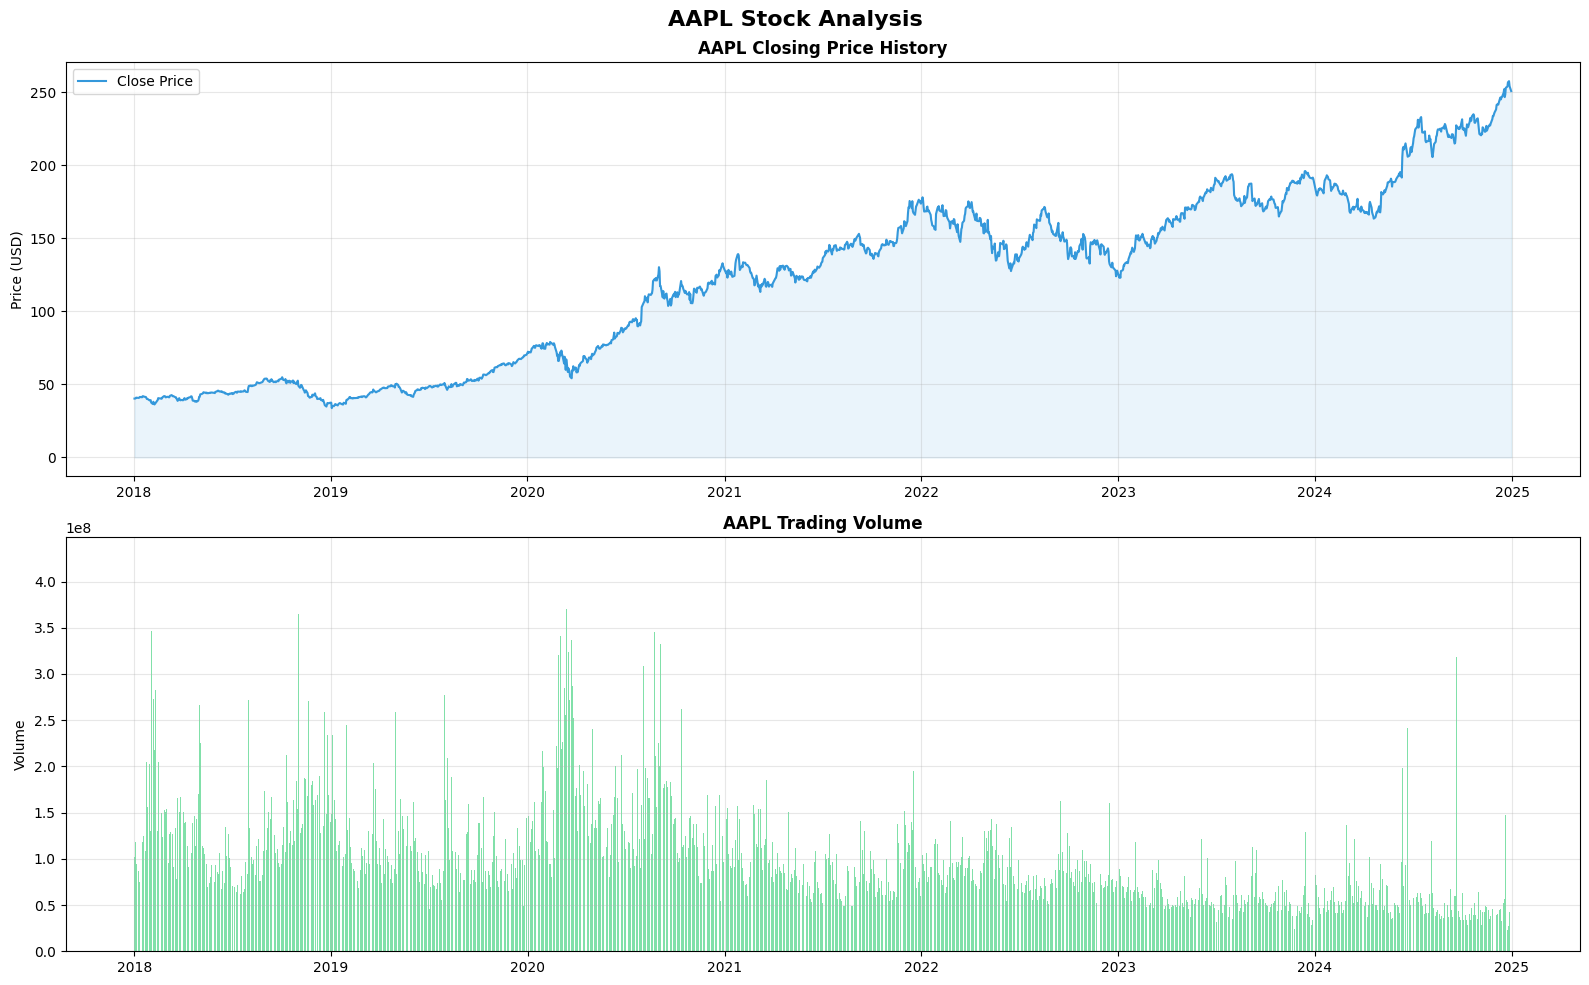

Saved: stock_history.png


In [15]:
# ── Stock price history ───────────────────────────────────────
# Check for missing values in the data
missing_close = df_primary[('Close', PRIMARY)].isnull().sum()
missing_volume = df_primary[('Volume', PRIMARY)].isnull().sum()

if missing_close > 0 or missing_volume > 0:
    raise ValueError(f'Data contains missing values: Close={missing_close}, Volume={missing_volume}. Please clean the data before plotting.')

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle(f'{PRIMARY} Stock Analysis', fontsize=16, fontweight='bold')

# Price history
axes[0].plot(df_primary.index, df_primary[('Close', PRIMARY)],
             color='#3498db', lw=1.5, label='Close Price')
axes[0].fill_between(df_primary.index, df_primary[('Close', PRIMARY)],
                      alpha=0.1, color='#3498db')
axes[0].set_title(f'{PRIMARY} Closing Price History', fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Volume
axes[1].bar(df_primary.index, df_primary[('Volume', PRIMARY)],
            color='#2ecc71', alpha=0.6, width=1)
axes[1].set_title(f'{PRIMARY} Trading Volume', fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('stock_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stock_history.png')

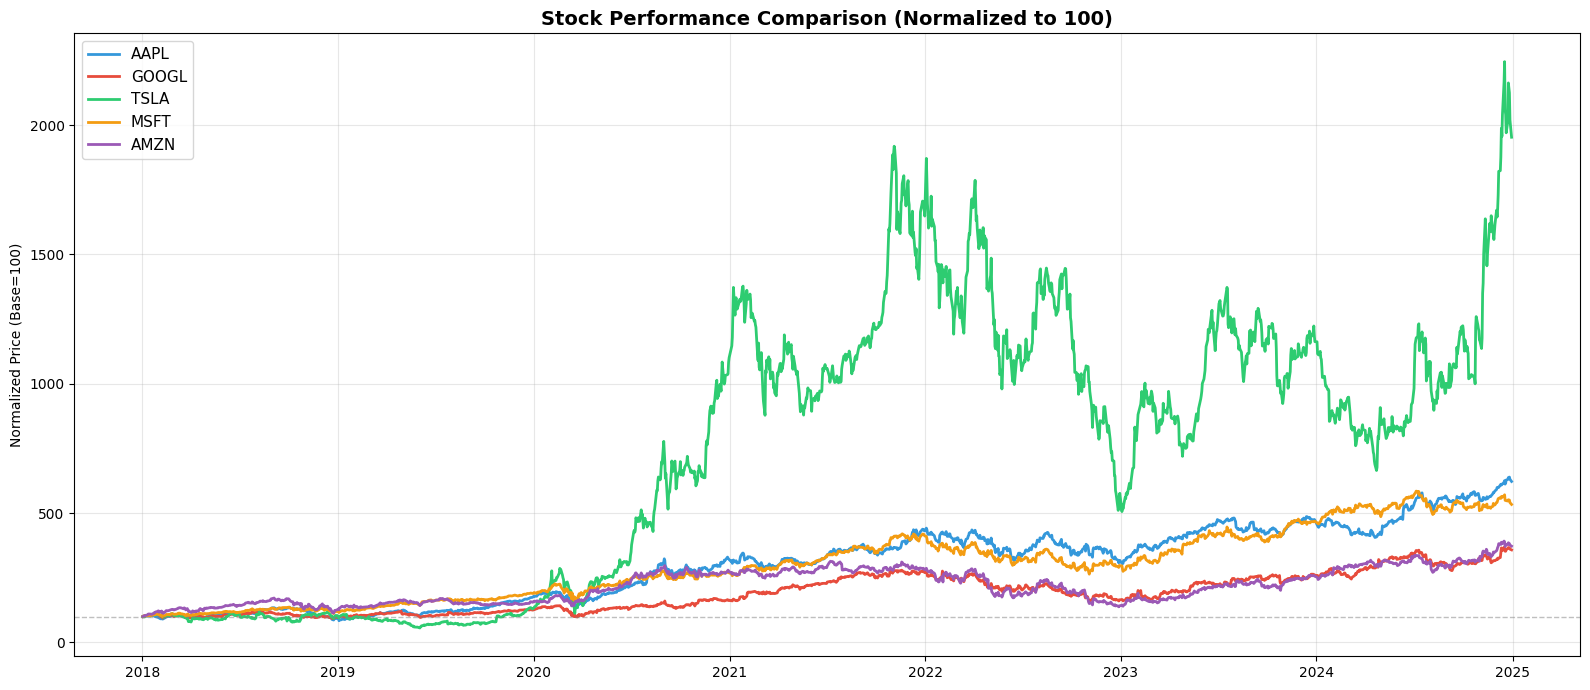

Saved: stocks_comparison.png


In [4]:
# ── Multiple stocks comparison ────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
colors  = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']

for ticker, color in zip(STOCKS, colors):
    # Normalize to 100 for fair comparison
    close = stock_data[ticker]['Close']
    normalized = (close / close.iloc[0]) * 100
    ax.plot(stock_data[ticker].index, normalized,
            color=color, lw=2, label=ticker)

ax.axhline(y=100, color='gray', linestyle='--', lw=1, alpha=0.5)
ax.set_title('Stock Performance Comparison (Normalized to 100)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Normalized Price (Base=100)')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('stocks_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stocks_comparison.png')

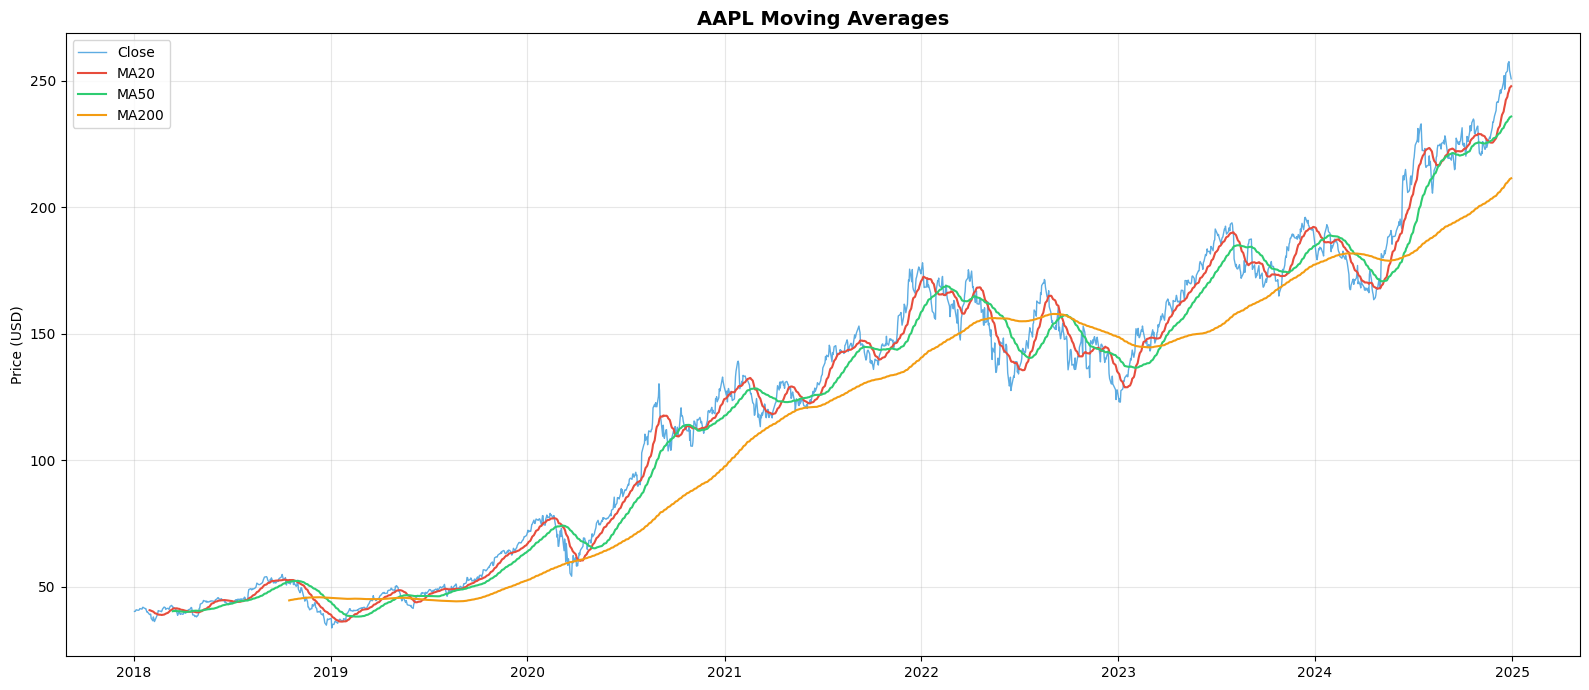

Saved: moving_averages.png


In [5]:
# ── Moving averages ───────────────────────────────────────────
df_ma = df_primary.copy()
df_ma['MA20']  = df_ma['Close'].rolling(window=20).mean()
df_ma['MA50']  = df_ma['Close'].rolling(window=50).mean()
df_ma['MA200'] = df_ma['Close'].rolling(window=200).mean()

plt.figure(figsize=(16, 7))
plt.plot(df_ma.index, df_ma['Close'], color='#3498db', lw=1, label='Close', alpha=0.8)
plt.plot(df_ma.index, df_ma['MA20'],  color='#e74c3c', lw=1.5, label='MA20')
plt.plot(df_ma.index, df_ma['MA50'],  color='#2ecc71', lw=1.5, label='MA50')
plt.plot(df_ma.index, df_ma['MA200'], color='#f39c12', lw=1.5, label='MA200')
plt.title(f'{PRIMARY} Moving Averages', fontsize=14, fontweight='bold')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: moving_averages.png')

## ⚙️ Step 4 — Prepare Data for LSTM

In [6]:
# ── Use Close price only ─────────────────────────────────────
close_prices = df_primary[['Close']].values

# ── Scale to [0, 1] ──────────────────────────────────────────
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(close_prices)

# ── Create sequences ─────────────────────────────────────────
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, SEQ_LEN)

# ── Train / Test split (80/20) ────────────────────────────────
split     = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape for LSTM [samples, timesteps, features]
X_train = X_train.reshape(-1, SEQ_LEN, 1)
X_test  = X_test.reshape(-1,  SEQ_LEN, 1)

print(f'Total sequences  : {len(X):,}')
print(f'Train sequences  : {len(X_train):,}')
print(f'Test sequences   : {len(X_test):,}')
print(f'Input shape      : {X_train.shape}')
print(f'Sequence length  : {SEQ_LEN} days')
print('Data ready for LSTM!')

Total sequences  : 1,700
Train sequences  : 1,360
Test sequences   : 340
Input shape      : (1360, 60, 1)
Sequence length  : 60 days
Data ready for LSTM!


## 🧠 Step 5 — Build LSTM Model

In [7]:
def build_lstm(seq_len=60):
    """
    Stacked LSTM model for stock price prediction
    Architecture: 3 LSTM layers + Dense head
    """
    model = keras.Sequential([
        # Layer 1 — return sequences for stacking
        layers.LSTM(128, return_sequences=True,
                    input_shape=(seq_len, 1)),
        layers.Dropout(0.2),

        # Layer 2
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),

        # Layer 3
        layers.LSTM(32, return_sequences=False),
        layers.Dropout(0.2),

        # Dense head
        layers.Dense(16, activation='relu'),
        layers.Dense(1)   # output — next day price
    ], name='StockLSTM')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model


model = build_lstm(SEQ_LEN)
model.summary()

Model: "StockLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,929 (503.63 KB)

 Trainable params: 128,929 (503.63 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ── Train LSTM ───────────────────────────────────────────────
lstm_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=4, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_lstm.keras', monitor='val_loss',
                               save_best_only=True, verbose=1)
]

print(f'Training LSTM on {PRIMARY} stock data...')
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=lstm_callbacks,
    verbose=1
)
print('Training complete!')

Training LSTM on AAPL stock data...
Epoch 1/50
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0474 - mae: 0.1529
Epoch 1: val_loss improved from None to 0.00286, saving model to best_lstm.keras

Epoch 1: finished saving model to best_lstm.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - loss: 0.0200 - mae: 0.0928 - val_loss: 0.0029 - val_mae: 0.0466 - learning_rate: 0.0010
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0029 - mae: 0.0377
Epoch 2: val_loss did not improve from 0.00286
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0029 - mae: 0.0368 - val_loss: 0.0077 - val_mae: 0.0834 - learning_rate: 0.0010
Epoch 3/50
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0023 - mae: 0.0330
Epoch 3: val_loss did not improve from 0.00286
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0023 - mae: 0.0329 - val_loss: 0.0035 - val_mae: 0.0533 - learning_rate: 0.0010
Epoch 4/50
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0025 - mae: 0.0343
Epoch 4: val_loss did not im

## 📊 Step 6 — Training Visualization

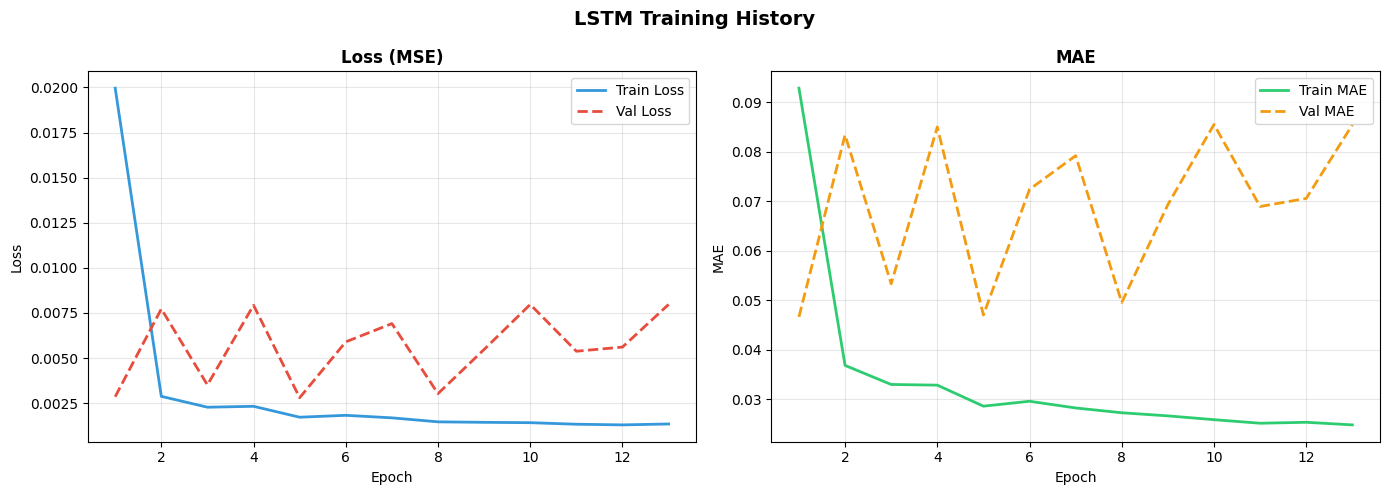

Saved: training_history.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Training History', fontsize=14, fontweight='bold')

ep = range(1, len(history.history['loss'])+1)
axes[0].plot(ep, history.history['loss'],     color='#3498db', lw=2, label='Train Loss')
axes[0].plot(ep, history.history['val_loss'], color='#e74c3c', lw=2, linestyle='--', label='Val Loss')
axes[0].set_title('Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history.history['mae'],     color='#2ecc71', lw=2, label='Train MAE')
axes[1].plot(ep, history.history['val_mae'], color='#f39c12', lw=2, linestyle='--', label='Val MAE')
axes[1].set_title('MAE', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_history.png')

## 📈 Step 7 — Predictions & Evaluation

In [10]:
# ── Make predictions ─────────────────────────────────────────
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred        = scaler.inverse_transform(y_pred_scaled)
y_actual      = scaler.inverse_transform(y_test.reshape(-1,1))

# ── Metrics ──────────────────────────────────────────────────
mae  = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2   = r2_score(y_actual, y_pred)
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

print('='*50)
print(f'  LSTM PREDICTION RESULTS — {PRIMARY}')
print('='*50)
print(f'  MAE   : ${mae:.2f}')
print(f'  RMSE  : ${rmse:.2f}')
print(f'  R2    : {r2:.4f}')
print(f'  MAPE  : {mape:.2f}%')
print('='*50)

  LSTM PREDICTION RESULTS — AAPL
  MAE   : $21.00
  RMSE  : $24.62
  R2    : 0.0140
  MAPE  : 9.97%


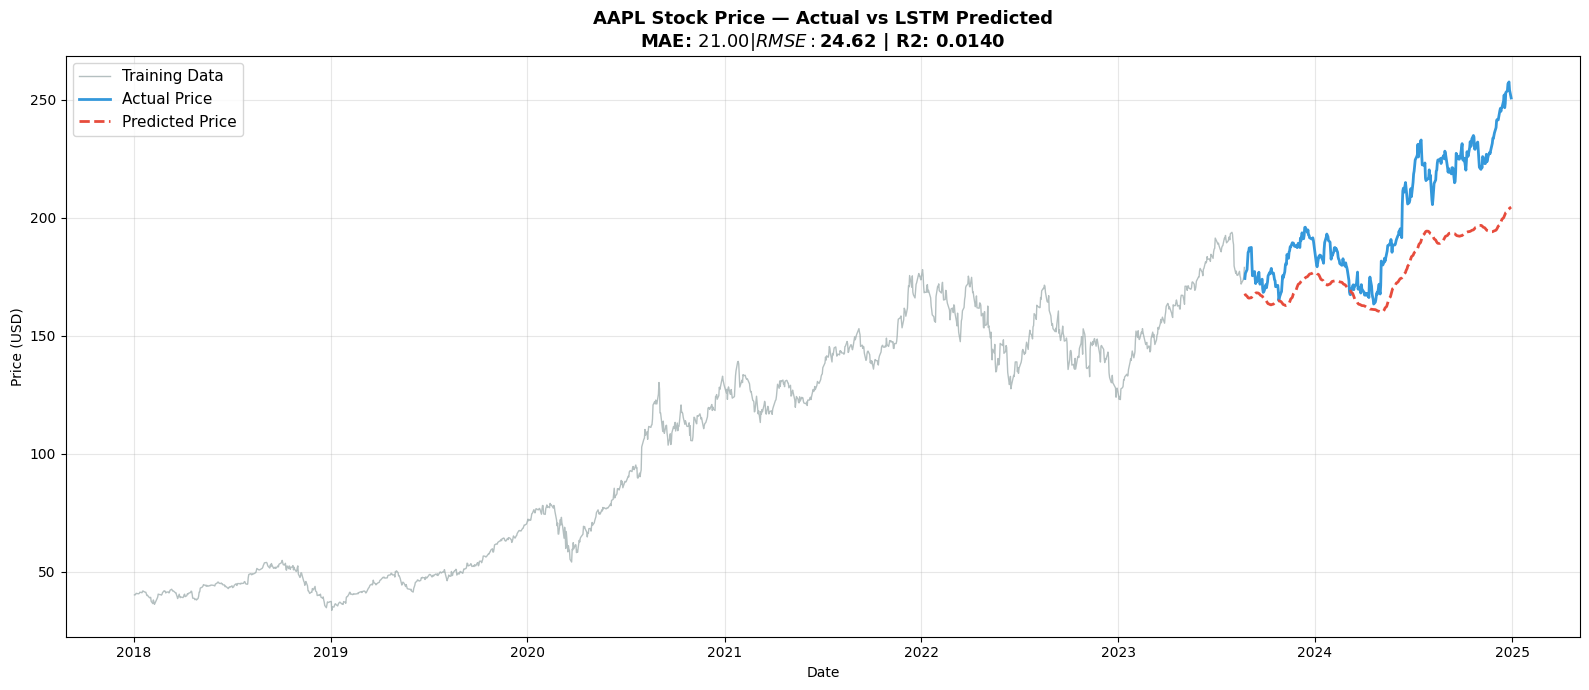

Saved: actual_vs_predicted.png


In [11]:
# ── Actual vs Predicted chart ─────────────────────────────────
test_dates = df_primary.index[SEQ_LEN + split:]

plt.figure(figsize=(16, 7))
plt.plot(df_primary.index[:split+SEQ_LEN],
         df_primary['Close'].values[:split+SEQ_LEN],
         color='#95a5a6', lw=1, label='Training Data', alpha=0.7)
plt.plot(test_dates, y_actual,
         color='#3498db', lw=2, label='Actual Price')
plt.plot(test_dates, y_pred,
         color='#e74c3c', lw=2, linestyle='--', label='Predicted Price')
plt.title(f'{PRIMARY} Stock Price — Actual vs LSTM Predicted\nMAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R2: {r2:.4f}',
          fontsize=13, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Price (USD)')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: actual_vs_predicted.png')

## 🔮 Step 8 — Predict Future Prices

In [20]:
def predict_future(model, data, scaler, seq_len, n_days=30):
    """
    Predict next n_days stock prices
    """
    # Ensure data is reshaped correctly for scaler
    last_sequence = scaler.transform(data[-seq_len:].reshape(-1, 1))
    predictions = []
    current_seq = last_sequence.copy()

    for _ in range(n_days):
        x_input = current_seq[-seq_len:].reshape(1, seq_len, 1)
        next_pred = model.predict(x_input, verbose=0)[0, 0]
        predictions.append(next_pred)
        current_seq = np.append(current_seq, [[next_pred]], axis=0)

    # Inverse transform predictions
    future_prices = scaler.inverse_transform(
        np.array(predictions).reshape(-1, 1)
    ).flatten()
    return future_prices


# Predict next 30 days
close_vals = df_primary['Close'].values
future_prices = predict_future(model, close_vals, scaler, SEQ_LEN, FUTURE_DAYS)

# Generate future dates
last_date = pd.to_datetime(df_primary.index[-1])  # Ensure datetime format
future_dates = pd.bdate_range(start=last_date, periods=FUTURE_DAYS + 1)[1:]

print(f'\nNext {FUTURE_DAYS} Day Price Forecast — {PRIMARY}')
print('=' * 40)
print(f'Last actual price : ${close_vals[-1].item():.2f}')  # Extract scalar value
print(f'Day 1 forecast    : ${future_prices[0]:.2f}')
print(f'Day 7 forecast    : ${future_prices[6]:.2f}')
print(f'Day 30 forecast   : ${future_prices[-1]:.2f}')
change = ((future_prices[-1] - close_vals[-1].item()) / close_vals[-1].item()) * 100
print(f'30-day change     : {change:+.2f}%')
print('=' * 40)


Next 30 Day Price Forecast — AAPL
Last actual price : $250.83
Day 1 forecast    : $204.99
Day 7 forecast    : $201.32
Day 30 forecast   : $168.38
30-day change     : -32.87%


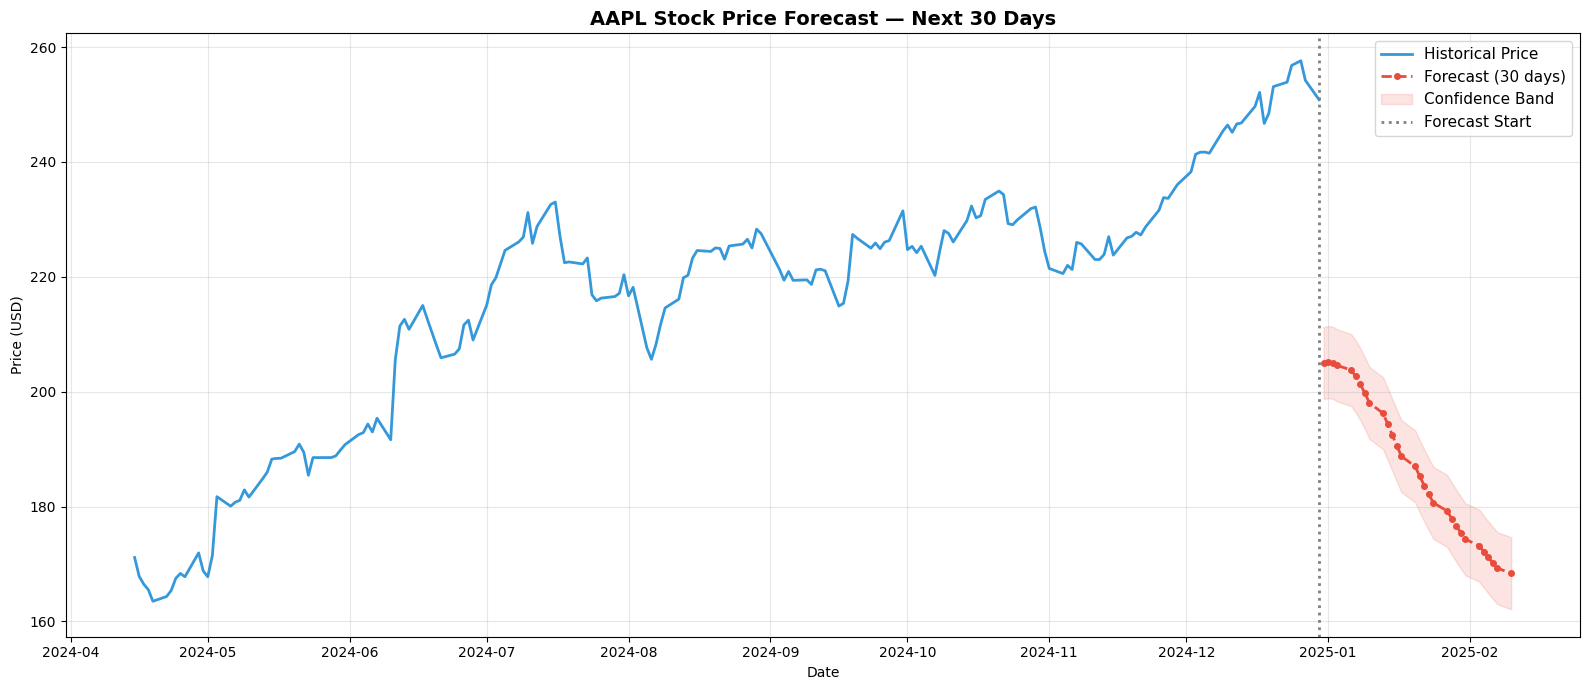

Saved: future_forecast.png


In [21]:
# ── Future price chart ────────────────────────────────────────
plt.figure(figsize=(16, 7))

# Last 180 days of actual data
plt.plot(df_primary.index[-180:],
         df_primary['Close'].values[-180:],
         color='#3498db', lw=2, label='Historical Price')

# Future predictions
plt.plot(future_dates, future_prices,
         color='#e74c3c', lw=2, linestyle='--',
         marker='o', markersize=4, label=f'Forecast ({FUTURE_DAYS} days)')

# Confidence band
std = np.std(future_prices) * 0.5
plt.fill_between(future_dates,
                 future_prices - std,
                 future_prices + std,
                 alpha=0.15, color='#e74c3c', label='Confidence Band')

# Vertical line at prediction start
plt.axvline(x=last_date, color='gray', linestyle=':', lw=2, label='Forecast Start')

plt.title(f'{PRIMARY} Stock Price Forecast — Next {FUTURE_DAYS} Days',
          fontsize=14, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Price (USD)')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('future_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: future_forecast.png')

## 🔄 Step 9 — Predict Any Stock


Predicting: GOOGL
Downloaded: 1,760 trading days


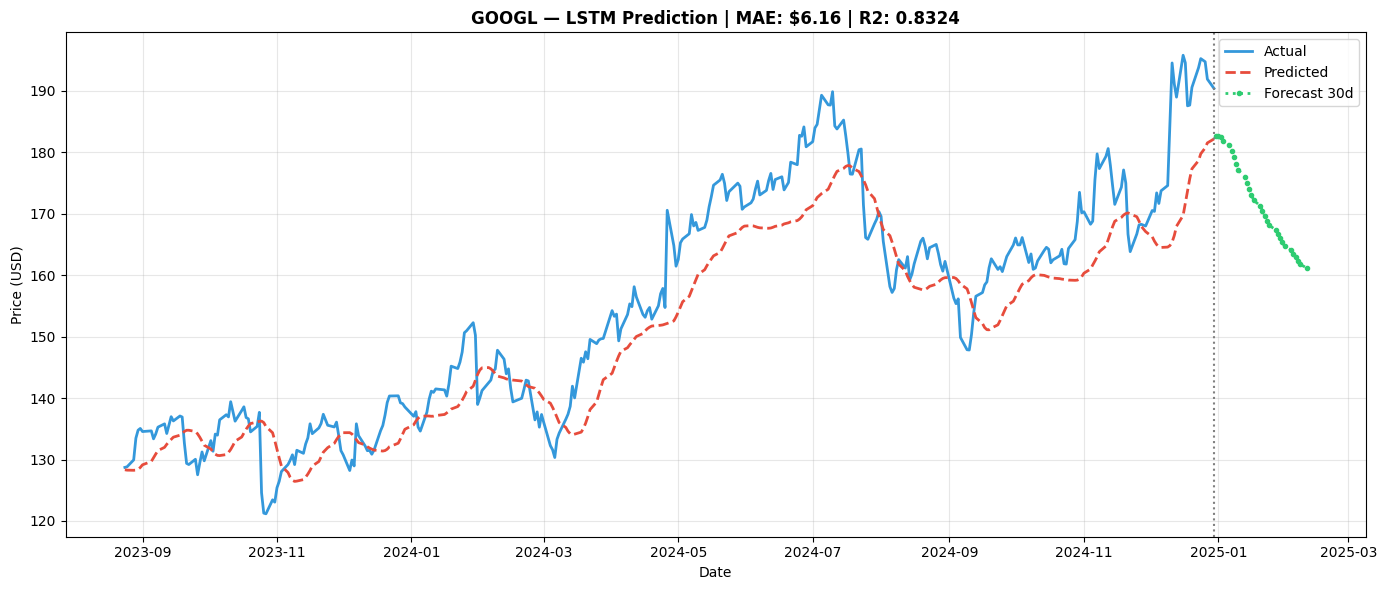

MAE    : $6.16
R2     : 0.8324
Last   : $190.36
Day 30 : $161.20
Change : -15.32%

Predicting: TSLA
Downloaded: 1,760 trading days


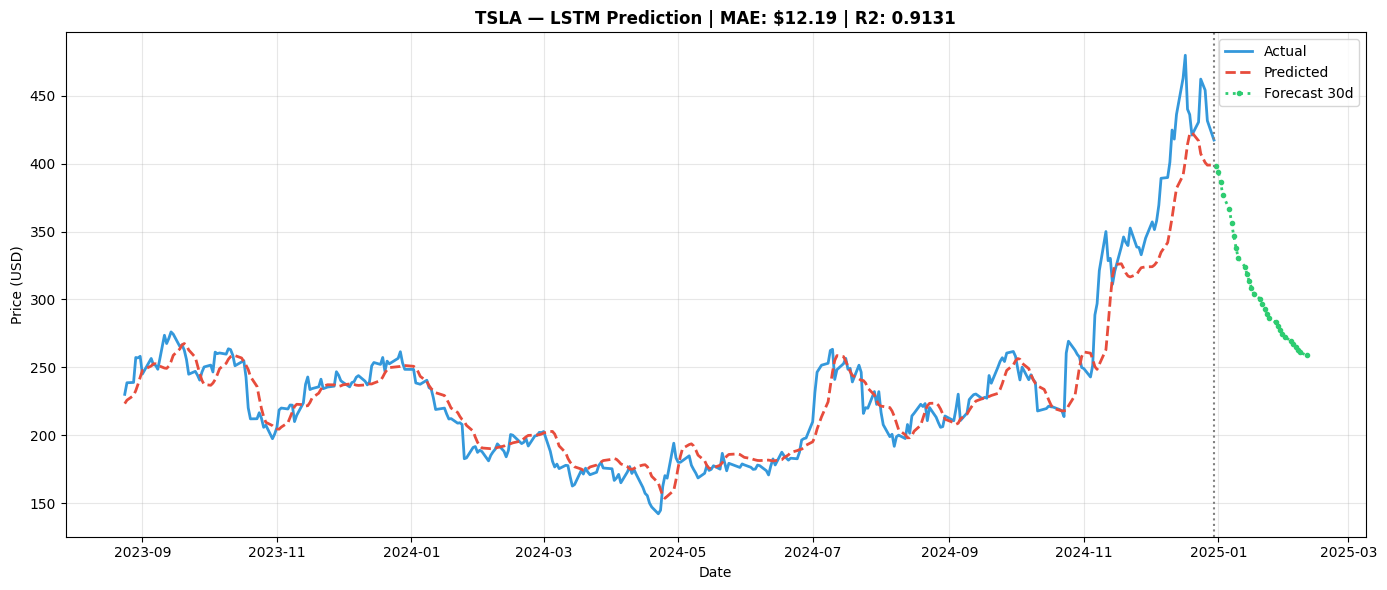

MAE    : $12.19
R2     : 0.9131
Last   : $417.41
Day 30 : $258.94
Change : -37.97%


(<Sequential name=StockLSTM, built=True>, MinMaxScaler())

In [22]:
def predict_stock(ticker, start='2018-01-01', end='2024-12-31',
                  seq_len=60, epochs=30, future_days=30):
    """
    Full pipeline — predict any stock from scratch.
    Usage: predict_stock('GOOGL')
           predict_stock('TSLA')
           predict_stock('MSFT')
    """
    print(f'\nPredicting: {ticker}')
    print('='*40)

    # Download
    df   = yf.download(ticker, start=start, end=end, progress=False)
    close = df[['Close']].values
    print(f'Downloaded: {len(df):,} trading days')

    # Scale
    sc  = MinMaxScaler()
    sc_data = sc.fit_transform(close)

    # Sequences
    X, y = create_sequences(sc_data, seq_len)
    split = int(len(X) * 0.8)
    X_tr = X[:split].reshape(-1, seq_len, 1)
    X_te = X[split:].reshape(-1, seq_len, 1)
    y_tr, y_te = y[:split], y[split:]

    # Build & train
    m = build_lstm(seq_len)
    m.fit(X_tr, y_tr, validation_split=0.1,
          epochs=epochs, batch_size=32, verbose=0,
          callbacks=[callbacks.EarlyStopping(patience=5,
                     restore_best_weights=True)])

    # Predict
    y_pred = sc.inverse_transform(m.predict(X_te, verbose=0))
    y_act  = sc.inverse_transform(y_te.reshape(-1,1))
    mae_v  = mean_absolute_error(y_act, y_pred)
    r2_v   = r2_score(y_act, y_pred)

    # Future
    fp = predict_future(m, close.flatten(), sc, seq_len, future_days)

    # Plot
    plt.figure(figsize=(14,6))
    test_dates = df.index[seq_len+split:]
    plt.plot(test_dates, y_act,  color='#3498db', lw=2, label='Actual')
    plt.plot(test_dates, y_pred, color='#e74c3c', lw=2,
             linestyle='--', label='Predicted')
    future_dates = pd.bdate_range(start=df.index[-1], periods=future_days+1)[1:]
    plt.plot(future_dates, fp, color='#2ecc71', lw=2,
             linestyle=':', marker='o', markersize=3,
             label=f'Forecast {future_days}d')
    plt.axvline(x=df.index[-1], color='gray', linestyle=':', lw=1.5)
    plt.title(f'{ticker} — LSTM Prediction | MAE: ${mae_v:.2f} | R2: {r2_v:.4f}',
              fontweight='bold')
    plt.ylabel('Price (USD)'); plt.xlabel('Date')
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'prediction_{ticker}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'MAE    : ${mae_v:.2f}')
    print(f'R2     : {r2_v:.4f}')
    print(f'Last   : ${close[-1][0]:.2f}')
    print(f'Day 30 : ${fp[-1]:.2f}')
    print(f'Change : {((fp[-1]-close[-1][0])/close[-1][0])*100:+.2f}%')
    return m, sc


# Test on multiple stocks
predict_stock('GOOGL')
predict_stock('TSLA')

## 🏆 Step 10 — Final Summary

In [ ]:
print('='*55)
print('  STOCK PRICE LSTM — FINAL SUMMARY')
print('='*55)
print(f'  Model         : Stacked LSTM (3 layers)')
print(f'  Primary Stock : {PRIMARY}')
print(f'  MAE           : ${mae:.2f}')
print(f'  RMSE          : ${rmse:.2f}')
print(f'  R2 Score      : {r2:.4f}')
print(f'  MAPE          : {mape:.2f}%')
print(f'  Forecast      : Next {FUTURE_DAYS} days')
print('='*55)
print('\nPortfolio images saved:')
for f in [
    'stock_history.png',
    'stocks_comparison.png',
    'moving_averages.png',
    'training_history.png',
    'actual_vs_predicted.png',
    'future_forecast.png',
]:
    print(f'   {f}')

  STOCK PRICE LSTM — FINAL SUMMARY
  Model         : Stacked LSTM (3 layers)
  Primary Stock : AAPL
  MAE           : $21.00
  RMSE          : $24.62
  R2 Score      : 0.0140
  MAPE          : 9.97%
  Forecast      : Next 30 days

Portfolio images saved:
  ✅ stock_history.png
  ✅ stocks_comparison.png
  ✅ moving_averages.png
  ✅ training_history.png
  ✅ actual_vs_predicted.png
  ✅ future_forecast.png


In [24]:
# Debugging Step: Inspect df_primary structure and columns
print('Columns in df_primary:', df_primary.columns)
print('First few rows of df_primary:')
print(df_primary.head())

Columns in df_primary: MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])
First few rows of df_primary:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2018-01-02  40.304180  40.313541  39.602261  39.812839  102223600
2018-01-03  40.297157  40.839976  40.233987  40.367350  118071600
2018-01-04  40.484329  40.587278  40.262056  40.369681   89738400
2018-01-05  40.945255  41.031824  40.489009  40.580258   94640000
2018-01-08  40.793182  41.087987  40.694911  40.793182   82271200
